In [1]:
!pip install kaggle

In [2]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d jackksoncsie/spam-email-dataset

Dataset URL: https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset
License(s): GNU Lesser General Public License 3.0
  0% 0.00/2.86M [00:00<?, ?B/s]
100% 2.86M/2.86M [00:00<00:00, 1.08GB/s]


In [5]:
import zipfile
with zipfile.ZipFile('spam-email-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
!ls -la

total 11696
drwxr-xr-x 1 root root    4096 Nov  2 15:02 .
drwxr-xr-x 1 root root    4096 Nov  2 14:59 ..
drwxr-xr-x 4 root root    4096 Oct 30 13:36 .config
-rw-r--r-- 1 root root 8954755 Nov  2 15:02 emails.csv
-rw-r--r-- 1 root root      63 Nov  2 15:01 kaggle.json
drwxr-xr-x 1 root root    4096 Oct 30 13:36 sample_data
-rw-r--r-- 1 root root 2994798 Sep  1  2023 spam-email-dataset.zip


In [7]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU available: True
GPU name: Tesla T4


In [8]:
df = pd.read_csv('/content/emails.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nLabel distribution:")
print(df.iloc[:, -1].value_counts())

Dataset Shape: (5728, 2)

Column Names:
['text', 'spam']

First few rows:
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB
None

Label distribution:
spam
0    4360
1    1368
Name: count, dtype: int64


In [9]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

print(f"\nFinal class distribution:")
print(df['spam'].value_counts())
print(f"Class ratio (majority:minority): {df['spam'].value_counts()[0]/df['spam'].value_counts()[1]:.2f}:1")

print(f"\nSample legitimate email:")
print(df[df['spam']==0]['text'].iloc[0][:200])
print(f"\nSample spam email:")
print(df[df['spam']==1]['text'].iloc[0][:200])

Missing values:
text    0
spam    0
dtype: int64

Duplicate rows: 33
Removing duplicates...
Dataset shape after removing duplicates: (5695, 2)

Final class distribution:
spam
0    4327
1    1368
Name: count, dtype: int64
Class ratio (majority:minority): 3.16:1

Sample legitimate email:
Subject: hello guys ,  i ' m " bugging you " for your completed questionnaire and for a one - page  bio / statement on your thoughts on " business edu and the new economy " . if  my records are incorr

Sample spam email:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , st


In [10]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^\w\s.!?,-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

print("Testing preprocessing on sample texts:")
sample_spam = df[df['spam']==1]['text'].iloc[0]
sample_legit = df[df['spam']==0]['text'].iloc[0]

print("Original spam text:")
print(sample_spam[:150])
print("\nPreprocessed spam text:")
print(preprocess_text(sample_spam)[:150])

print("\nOriginal legitimate text:")
print(sample_legit[:150])
print("\nPreprocessed legitimate text:")
print(preprocess_text(sample_legit)[:150])

Testing preprocessing on sample texts:
Original spam text:
Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the informa

Preprocessed spam text:
subject naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information 

Original legitimate text:
Subject: hello guys ,  i ' m " bugging you " for your completed questionnaire and for a one - page  bio / statement on your thoughts on " business edu

Preprocessed legitimate text:
subject hello guys , i m bugging you for your completed questionnaire and for a one - page bio statement on your thoughts on business edu and the new 


Text length statistics (in words):
count    5695.000000
mean      294.463565
std       380.033480
min         2.000000
25%        95.000000
50%       195.000000
75%       363.000000
max      8050.000000
Name: processed_text, dtype: float64

Emails longer than 512 words: 797
Emails longer than 256 words: 2179


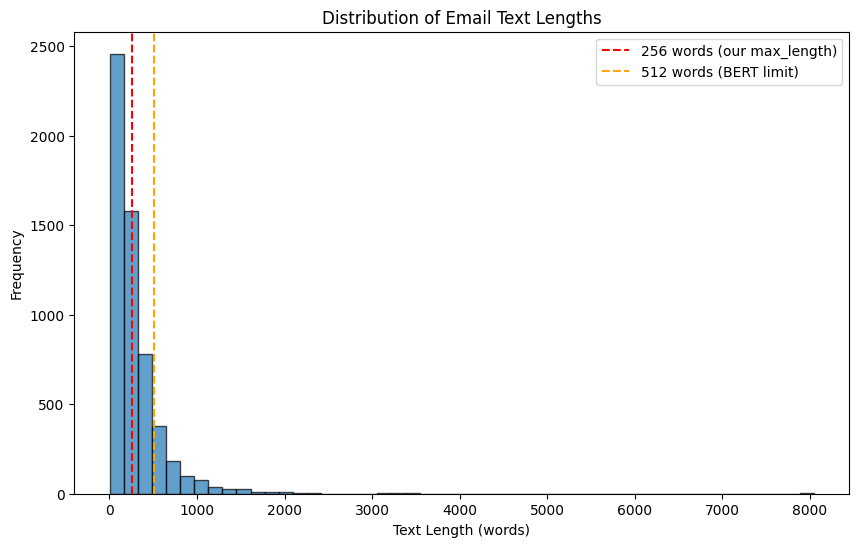


Dataset shape: (5695, 3)
Sample processed text length: 311 words


In [11]:
df['processed_text'] = df['text'].apply(preprocess_text)

text_lengths = df['processed_text'].str.split().str.len()
print("Text length statistics (in words):")
print(text_lengths.describe())

print(f"\nEmails longer than 512 words: {(text_lengths > 512).sum()}")
print(f"Emails longer than 256 words: {(text_lengths > 256).sum()}")

plt.figure(figsize=(10, 6))
plt.hist(text_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Text Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Email Text Lengths')
plt.axvline(x=256, color='red', linestyle='--', label='256 words (our max_length)')
plt.axvline(x=512, color='orange', linestyle='--', label='512 words (BERT limit)')
plt.legend()
plt.show()

print(f"\nDataset shape: {df.shape}")
print(f"Sample processed text length: {len(df['processed_text'].iloc[0].split())} words")

In [12]:
X = df['processed_text'].values
y = df['spam'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print("Dataset splits:")
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

print(f"\nClass distribution in training set:")
train_counts = np.bincount(y_train)
print(f"Legitimate (0): {train_counts[0]} ({train_counts[0]/len(y_train)*100:.1f}%)")
print(f"Spam (1): {train_counts[1]} ({train_counts[1]/len(y_train)*100:.1f}%)")
print(f"Ratio: {train_counts[0]/train_counts[1]:.2f}:1")

Dataset splits:
Training set: 4556 samples
Validation set: 569 samples
Test set: 570 samples

Class distribution in training set:
Legitimate (0): 3462 (76.0%)
Spam (1): 1094 (24.0%)
Ratio: 3.16:1


In [13]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Calculated class weights:")
print(f"Legitimate (0): {class_weights[0]:.3f}")
print(f"Spam (1): {class_weights[1]:.3f}")
print(f"Spam weight is {class_weights[1]/class_weights[0]:.2f}x higher than legitimate")

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"\nClass weights tensor: {class_weights_tensor}")

Calculated class weights:
Legitimate (0): 0.658
Spam (1): 2.082
Spam weight is 3.16x higher than legitimate

Class weights tensor: tensor([0.6580, 2.0823], device='cuda:0')


In [14]:
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

sample_texts = [X_train[0], X_train[100]]
print("Testing tokenization:")

for i, text in enumerate(sample_texts):
    print(f"\nSample {i+1}:")
    print(f"Original text (first 100 chars): {text[:100]}...")

    encoded = tokenizer(
        text,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    print(f"Tokenized length: {encoded['input_ids'].shape}")
    print(f"Attention mask shape: {encoded['attention_mask'].shape}")
    print(f"Number of actual tokens (non-padded): {encoded['attention_mask'].sum().item()}")

print(f"\nTokenizer vocab size: {tokenizer.vocab_size}")
print(f"Max model length: {tokenizer.model_max_length}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Testing tokenization:

Sample 1:
Original text (first 100 chars): subject re resume of carla di castro vince , we have many associates that we have to place within bu...
Tokenized length: torch.Size([1, 256])
Attention mask shape: torch.Size([1, 256])
Number of actual tokens (non-padded): 192

Sample 2:
Original text (first 100 chars): subject re b . brandfass barbara , my apologies . i was traveling and then we had the usual end of t...
Tokenized length: torch.Size([1, 256])
Attention mask shape: torch.Size([1, 256])
Number of actual tokens (non-padded): 157

Tokenizer vocab size: 50265
Max model length: 512


In [15]:
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = EmailDataset(X_train, y_train, tokenizer)
val_dataset = EmailDataset(X_val, y_val, tokenizer)
test_dataset = EmailDataset(X_test, y_test, tokenizer)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

sample = train_dataset[0]
print(f"\nSample data shapes:")
print(f"Input IDs: {sample['input_ids'].shape}")
print(f"Attention mask: {sample['attention_mask'].shape}")
print(f"Label: {sample['labels']}")

Training dataset size: 4556
Validation dataset size: 569
Test dataset size: 570

Sample data shapes:
Input IDs: torch.Size([256])
Attention mask: torch.Size([256])
Label: 0


In [16]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"Input IDs: {sample_batch['input_ids'].shape}")
print(f"Attention mask: {sample_batch['attention_mask'].shape}")
print(f"Labels: {sample_batch['labels'].shape}")
print(f"Labels in batch: {sample_batch['labels'].tolist()}")

Training batches: 285
Validation batches: 36
Test batches: 36

Sample batch shapes:
Input IDs: torch.Size([16, 256])
Attention mask: torch.Size([16, 256])
Labels: torch.Size([16])
Labels in batch: [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0]


In [17]:
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded successfully!")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device: {next(model.parameters()).device}")

print(f"\nModel architecture:")
print(f"- RoBERTa base encoder: 12 layers")
print(f"- Classification head: Linear layer (768 -> 2)")
print(f"- Dropout: Built-in (0.1)")

test_input = sample_batch['input_ids'][:2].to(device)
test_attention = sample_batch['attention_mask'][:2].to(device)

with torch.no_grad():
    outputs = model(input_ids=test_input, attention_mask=test_attention)
    print(f"\nTest forward pass:")
    print(f"Output logits shape: {outputs.logits.shape}")
    print(f"Sample logits: {outputs.logits}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!
Total parameters: 124,647,170
Trainable parameters: 124,647,170
Model device: cuda:0

Model architecture:
- RoBERTa base encoder: 12 layers
- Classification head: Linear layer (768 -> 2)
- Dropout: Built-in (0.1)

Test forward pass:
Output logits shape: torch.Size([2, 2])
Sample logits: tensor([[0.2123, 0.1707],
        [0.1882, 0.1574]], device='cuda:0')


In [18]:
from transformers import get_linear_schedule_with_warmup

epochs = 3
learning_rate = 2e-5

optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,
    eps=1e-8,
    weight_decay=0.01
)

total_steps = len(train_loader) * epochs
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Training configuration:")
print(f"Epochs: {epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Batch size: {batch_size}")
print(f"Weight decay: 0.01")
print(f"Loss function: CrossEntropyLoss with class weights")
print(f"Class weights: {class_weights_tensor}")

Training configuration:
Epochs: 3
Learning rate: 2e-05
Total training steps: 855
Warmup steps: 85
Batch size: 16
Weight decay: 0.01
Loss function: CrossEntropyLoss with class weights
Class weights: tensor([0.6580, 2.0823], device='cuda:0')


In [19]:
def train_epoch(model, data_loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples
    return avg_loss, accuracy

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.logits, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples
    return avg_loss, accuracy

print("Training functions defined. Starting training...")

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    print("-" * 30)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Training functions defined. Starting training...

Epoch 1/3
------------------------------
Train Loss: 0.2385, Train Acc: 0.9234
Val Loss: 0.0701, Val Acc: 0.9859

Epoch 2/3
------------------------------
Train Loss: 0.0320, Train Acc: 0.9939
Val Loss: 0.0398, Val Acc: 0.9877

Epoch 3/3
------------------------------
Train Loss: 0.0040, Train Acc: 0.9989
Val Loss: 0.0279, Val Acc: 0.9930


In [20]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

model.eval()
all_predictions = []
all_true_labels = []
all_probabilities = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = torch.softmax(outputs.logits, dim=1)
        _, predicted = torch.max(outputs.logits, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_true_labels, all_predictions)
recall = recall_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions)

print(f"\nDetailed Test Metrics:")
print(f"Precision (Spam): {precision:.4f}")
print(f"Recall (Spam): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=['Legitimate', 'Spam']))

Test Results:
Test Loss: 0.0106
Test Accuracy: 0.9947

Detailed Test Metrics:
Precision (Spam): 0.9786
Recall (Spam): 1.0000
F1-Score: 0.9892

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00       433
        Spam       0.98      1.00      0.99       137

    accuracy                           0.99       570
   macro avg       0.99      1.00      0.99       570
weighted avg       0.99      0.99      0.99       570



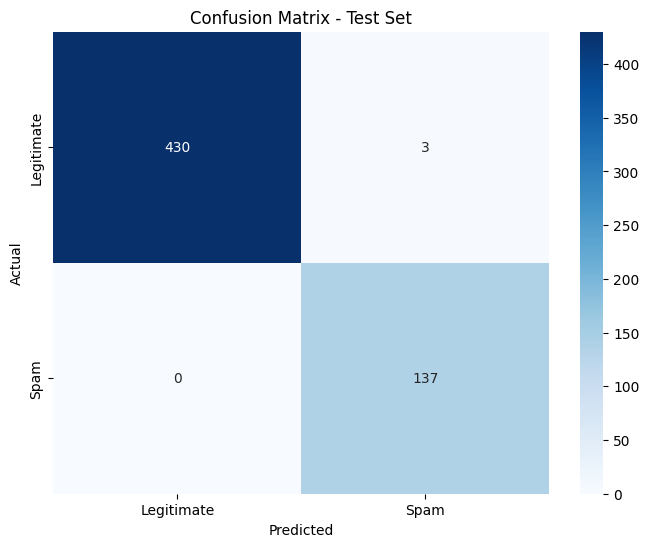

Confusion Matrix Analysis:
True Negatives (Legitimate correctly classified): 430
False Positives (Legitimate classified as Spam): 3
False Negatives (Spam classified as Legitimate): 0
True Positives (Spam correctly classified): 137

Model saved successfully!
Model weights: /content/roberta_phishing_model.pth
Tokenizer: /content/roberta_tokenizer/


In [21]:
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix Analysis:")
print(f"True Negatives (Legitimate correctly classified): {cm[0,0]}")
print(f"False Positives (Legitimate classified as Spam): {cm[0,1]}")
print(f"False Negatives (Spam classified as Legitimate): {cm[1,0]}")
print(f"True Positives (Spam correctly classified): {cm[1,1]}")

torch.save(model.state_dict(), '/content/roberta_phishing_model.pth')
tokenizer.save_pretrained('/content/roberta_tokenizer')

print(f"\nModel saved successfully!")
print(f"Model weights: /content/roberta_phishing_model.pth")
print(f"Tokenizer: /content/roberta_tokenizer/")

In [22]:
!pip install shap

import shap

class RobertaExplainer:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def predict_proba(self, texts):
        predictions = []
        for text in texts:
            encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=256,
                return_tensors='pt'
            )

            with torch.no_grad():
                input_ids = encoding['input_ids'].to(self.device)
                attention_mask = encoding['attention_mask'].to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()
                predictions.append(probabilities[0])

        return np.array(predictions)

roberta_explainer = RobertaExplainer(model, tokenizer, device)

sample_texts = [
    "urgent your account will be suspended click here immediately",
    "hi john please find the quarterly report attached"
]

test_predictions = roberta_explainer.predict_proba(sample_texts)
print("SHAP explainer setup successful!")
print(f"Test predictions shape: {test_predictions.shape}")
print(f"Sample predictions:")
for i, pred in enumerate(test_predictions):
    print(f"Text {i+1}: Legitimate={pred[0]:.3f}, Spam={pred[1]:.3f}")

SHAP explainer setup successful!
Test predictions shape: (2, 2)
Sample predictions:
Text 1: Legitimate=0.000, Spam=1.000
Text 2: Legitimate=1.000, Spam=0.000


In [24]:
def get_shap_word_importance(text, model, tokenizer, device):
    def model_predict(texts):
        predictions = []
        for t in texts:
            encoding = tokenizer(t, truncation=True, padding='max_length',
                               max_length=256, return_tensors='pt')
            with torch.no_grad():
                input_ids = encoding['input_ids'].to(device)
                attention_mask = encoding['attention_mask'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
                predictions.append(probs[0])
        return np.array(predictions)

    explainer = shap.Explainer(model_predict, shap.maskers.Text(tokenizer))
    shap_values = explainer([text])

    words = text.split()
    shap_scores = shap_values.values[0][:len(words), 1]  # Get spam class scores

    return words, shap_scores

def visualize_shap_explanation(text, words, shap_scores, prediction_result):
    plt.figure(figsize=(15, 8))

    word_importance = list(zip(words, shap_scores))
    word_importance.sort(key=lambda x: abs(x[1]), reverse=True)

    top_words = word_importance[:10]
    risky_words = [(w, s) for w, s in top_words if s > 0]
    safe_words = [(w, s) for w, s in top_words if s < 0]

    print(f"PREDICTION: {'PHISHING' if prediction_result['is_phishing'] else 'LEGITIMATE'}")
    print(f"CONFIDENCE: {prediction_result['confidence']:.1f}%")
    print(f"SPAM PROBABILITY: {prediction_result['probabilities']['spam']:.3f}")

    print(f"\nTOP RISKY WORDS (contribute to PHISHING):")
    for word, score in risky_words[:5]:
        print(f"  '{word}': {score:.3f}")

    print(f"\nTOP SAFE WORDS (contribute to LEGITIMATE):")
    for word, score in safe_words[:5]:
        print(f"  '{word}': {score:.3f}")

    colored_text = []
    for word, score in zip(words, shap_scores):
        if abs(score) > 0.01:
            if score > 0:
                colored_text.append(f"\033[91m{word}\033[0m")  # Red for risky
            else:
                colored_text.append(f"\033[92m{word}\033[0m")  # Green for safe
        else:
            colored_text.append(word)

    print(f"\nCOLORED TEXT (Red=Risky, Green=Safe):")
    print(" ".join(colored_text))

print("Testing SHAP visualization:")

test_phishing = "urgent your account will be suspended click here immediately to verify"
result1 = predict_with_shap_explanation(test_phishing, model, tokenizer, device, show_plot=False)
words1, scores1 = get_shap_word_importance(test_phishing, model, tokenizer, device)
visualize_shap_explanation(test_phishing, words1, scores1, result1)

print("\n" + "="*80 + "\n")

test_legitimate = "hi john please find the quarterly report attached as requested"
result2 = predict_with_shap_explanation(test_legitimate, model, tokenizer, device, show_plot=False)
words2, scores2 = get_shap_word_importance(test_legitimate, model, tokenizer, device)
visualize_shap_explanation(test_legitimate, words2, scores2, result2)

Testing SHAP visualization:


  0%|          | 0/182 [00:00<?, ?it/s]

PREDICTION: PHISHING
CONFIDENCE: 100.0%
SPAM PROBABILITY: 1.000

TOP RISKY WORDS (contribute to PHISHING):
  'be': 0.116
  'account': 0.099
  'immediately': 0.071
  'here': 0.026
  'to': 0.015

TOP SAFE WORDS (contribute to LEGITIMATE):
  'will': -0.106
  'suspended': -0.103
  'click': -0.034
  'verify': -0.009

COLORED TEXT (Red=Risky, Green=Safe):
urgent your account will be suspended click here immediately to verify


PREDICTION: LEGITIMATE
CONFIDENCE: 100.0%
SPAM PROBABILITY: 0.000

TOP RISKY WORDS (contribute to PHISHING):
  'the': 0.151
  'john': 0.056
  'as': 0.039

TOP SAFE WORDS (contribute to LEGITIMATE):
  'please': -0.430
  'report': -0.365
  'requested': -0.178
  'attached': -0.125
  'find': -0.047

COLORED TEXT (Red=Risky, Green=Safe):
hi john please find the quarterly report attached as requested


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

Creating SHAP bar plots:

1. PHISHING EMAIL ANALYSIS:


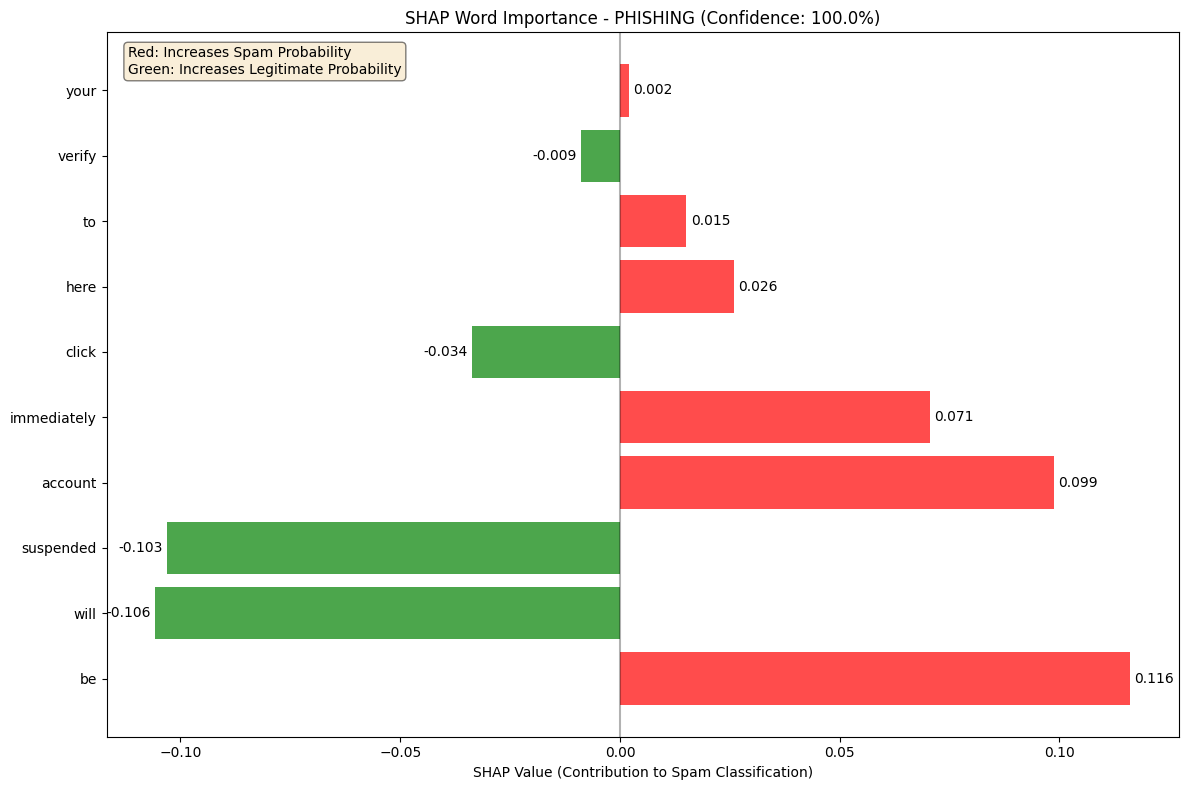


Original Text: 'urgent your account will be suspended click here immediately to verify'
Prediction: PHISHING
Confidence: 100.0%

2. LEGITIMATE EMAIL ANALYSIS:


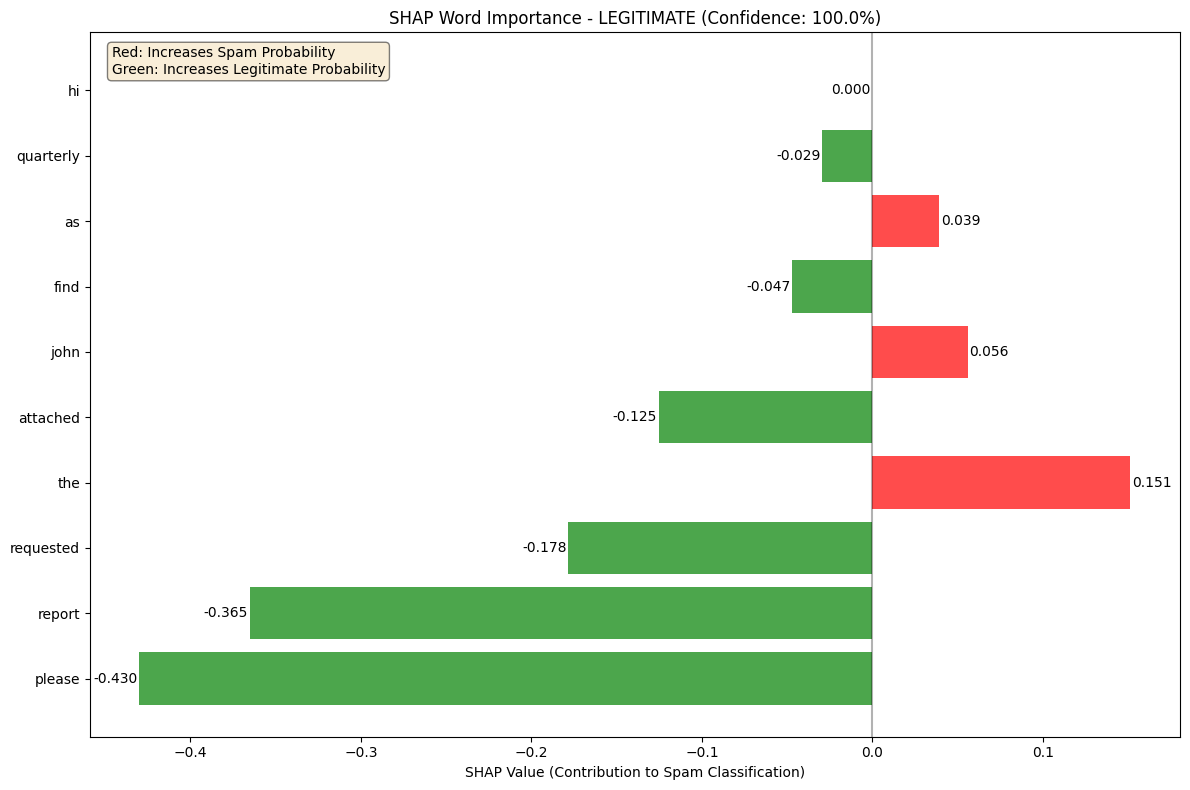


Original Text: 'hi john please find the quarterly report attached as requested'
Prediction: LEGITIMATE
Confidence: 100.0%


In [25]:
def create_shap_bar_plot(words, shap_scores, prediction_result, text):
    word_importance = list(zip(words, shap_scores))
    word_importance.sort(key=lambda x: abs(x[1]), reverse=True)

    top_words = word_importance[:10]
    words_list = [item[0] for item in top_words]
    scores_list = [item[1] for item in top_words]

    colors = ['red' if score > 0 else 'green' for score in scores_list]

    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(words_list)), scores_list, color=colors, alpha=0.7)

    plt.yticks(range(len(words_list)), words_list)
    plt.xlabel('SHAP Value (Contribution to Spam Classification)')
    plt.title(f'SHAP Word Importance - {prediction_result["is_phishing"] and "PHISHING" or "LEGITIMATE"} '
              f'(Confidence: {prediction_result["confidence"]:.1f}%)')

    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)

    for i, (word, score) in enumerate(zip(words_list, scores_list)):
        plt.text(score + 0.001 if score > 0 else score - 0.001, i,
                f'{score:.3f}', va='center',
                ha='left' if score > 0 else 'right')

    plt.text(0.02, 0.98, 'Red: Increases Spam Probability\nGreen: Increases Legitimate Probability',
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    print(f"\nOriginal Text: '{text}'")
    print(f"Prediction: {'PHISHING' if prediction_result['is_phishing'] else 'LEGITIMATE'}")
    print(f"Confidence: {prediction_result['confidence']:.1f}%")

print("Creating SHAP bar plots:")

print("\n1. PHISHING EMAIL ANALYSIS:")
create_shap_bar_plot(words1, scores1, result1, test_phishing)

print("\n2. LEGITIMATE EMAIL ANALYSIS:")
create_shap_bar_plot(words2, scores2, result2, test_legitimate)

In [27]:
def predict_email_text(text):
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=256,
        return_tensors='pt'
    )

    with torch.no_grad():
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    is_phishing = probabilities[1] > 0.5
    confidence = probabilities[1] * 100 if is_phishing else probabilities[0] * 100

    words, shap_scores = get_shap_word_importance(text, model, tokenizer, device)

    word_importance = list(zip(words, shap_scores))
    word_importance.sort(key=lambda x: abs(x[1]), reverse=True)

    risky_words = [(w, float(s)) for w, s in word_importance if s > 0.01][:10]
    safe_words = [(w, float(s)) for w, s in word_importance if s < -0.01][:10]

    return {
        'is_phishing': bool(is_phishing),
        'confidence': float(confidence),
        'prediction_value': float(probabilities[1]),
        'top_risky_words': risky_words,
        'top_safe_words': safe_words
    }

test_cases = [
    {
        "name": "Clear Phishing",
        "text": "Urgent! Your bank account will be suspended. Click here immediately to verify: http://fake-bank.com"
    },
    {
        "name": "Legitimate Business",
        "text": "Hi John, attached is the quarterly report you requested. Let me know if you need clarifications."
    },
    {
        "name": "Edge Case - Prize",
        "text": "Congratulations! You've won $1000. Claim your prize now!"
    },
    {
        "name": "Tricky Professional Phishing",
        "text": "Dear valued customer, we noticed suspicious activity on your account. Please verify your identity immediately by clicking the secure link below to avoid account suspension."
    }
]

print("FINAL MODEL TESTING - Edge Cases:")
print("="*80)

for i, case in enumerate(test_cases, 1):
    print(f"\nTest Case {i}: {case['name']}")
    print(f"Text: {case['text']}")

    result = predict_email_text(case['text'])

    print(f"Prediction: {'PHISHING' if result['is_phishing'] else 'LEGITIMATE'}")
    print(f"Confidence: {result['confidence']:.1f}%")
    print(f"Top risky words: {[w for w, s in result['top_risky_words'][:3]]}")
    print(f"Top safe words: {[w for w, s in result['top_safe_words'][:3]]}")
    print("-" * 60)

FINAL MODEL TESTING - Edge Cases:

Test Case 1: Clear Phishing
Text: Urgent! Your bank account will be suspended. Click here immediately to verify: http://fake-bank.com


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:10, 10.53s/it]               


Prediction: PHISHING
Confidence: 100.0%
Top risky words: ['suspended.']
Top safe words: []
------------------------------------------------------------

Test Case 2: Legitimate Business
Text: Hi John, attached is the quarterly report you requested. Let me know if you need clarifications.


  0%|          | 0/462 [00:00<?, ?it/s]

Prediction: LEGITIMATE
Confidence: 100.0%
Top risky words: ['me', 'the', 'know']
Top safe words: ['you', 'John,', 'attached']
------------------------------------------------------------

Test Case 3: Edge Case - Prize
Text: Congratulations! You've won $1000. Claim your prize now!
Prediction: PHISHING
Confidence: 100.0%
Top risky words: ['prize', 'Claim', 'now!']
Top safe words: ["You've", 'your']
------------------------------------------------------------

Test Case 4: Tricky Professional Phishing
Text: Dear valued customer, we noticed suspicious activity on your account. Please verify your identity immediately by clicking the secure link below to avoid account suspension.


  0%|          | 0/498 [00:00<?, ?it/s]

Prediction: PHISHING
Confidence: 100.0%
Top risky words: []
Top safe words: []
------------------------------------------------------------


In [29]:
import sys
import torch
import transformers
import sklearn
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import shap

print("LIBRARY VERSIONS CHECK:")
print("="*50)
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SHAP version: {shap.__version__}")
print(f"Torchvision: {shap.__version__}")

print(f"\nGPU Information:")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

LIBRARY VERSIONS CHECK:
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.8.0+cu126
Transformers version: 4.57.1
Scikit-learn version: 1.6.1
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
SHAP version: 0.49.1
Torchvision: 0.49.1

GPU Information:
CUDA available: True
CUDA version: 12.6
GPU device: Tesla T4
GPU memory: 14.7 GB


In [32]:
import os

existing_files = []
for file in ['roberta_tokenizer', 'sample_data', 'emails.csv', 'kaggle.json', 'roberta_phishing_model.pth', 'spam-email-dataset.zip']:
    if os.path.exists(file):
        existing_files.append(file)
        print(f"✓ Found: {file}")
    else:
        print(f"✗ Missing: {file}")

print(f"\nFiles to zip: {existing_files}")

✓ Found: roberta_tokenizer
✓ Found: sample_data
✓ Found: emails.csv
✓ Found: kaggle.json
✓ Found: roberta_phishing_model.pth
✓ Found: spam-email-dataset.zip

Files to zip: ['roberta_tokenizer', 'sample_data', 'emails.csv', 'kaggle.json', 'roberta_phishing_model.pth', 'spam-email-dataset.zip']


In [34]:
import zipfile
import os
from google.colab import files as colab_files

with zipfile.ZipFile('all_project_files.zip', 'w') as zipf:
    for file_name in ['roberta_tokenizer', 'sample_data', 'emails.csv', 'kaggle.json', 'roberta_phishing_model.pth', 'spam-email-dataset.zip']:
        if os.path.exists(file_name):
            if os.path.isdir(file_name):
                for root, dirs, files in os.walk(file_name):
                    for file_in_dir in files:
                        file_path = os.path.join(root, file_in_dir)
                        arcname = os.path.relpath(file_path, start='.')
                        zipf.write(file_path, arcname)
            else:
                zipf.write(file_name)

print("Zip file created successfully!")
print("Files included in the zip:")
with zipfile.ZipFile('all_project_files.zip', 'r') as zipf:
    for info in zipf.filelist:
        print(f"  - {info.filename}")

print("\nDownloading zip file...")
colab_files.download('all_project_files.zip')

Zip file created successfully!
Files included in the zip:
  - roberta_tokenizer/special_tokens_map.json
  - roberta_tokenizer/merges.txt
  - roberta_tokenizer/tokenizer_config.json
  - roberta_tokenizer/vocab.json
  - sample_data/anscombe.json
  - sample_data/README.md
  - sample_data/california_housing_train.csv
  - sample_data/mnist_test.csv
  - sample_data/mnist_train_small.csv
  - sample_data/california_housing_test.csv
  - emails.csv
  - kaggle.json
  - roberta_phishing_model.pth
  - spam-email-dataset.zip



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>